# EEG microstates under acute psilocybin

Reproduces the microstate analyses of

> Novický, Stoliker, Razi & Zeldenrust, *EEG microstates transition more rapidly
> and approximate entropy increases under acute psilocybin*.

The inputs (`data/df_microstates.csv`, `data/shared_variance.csv`,
`data/var_and_time.csv`) are direct exports of the **MICROSTATELAB** plugin for
EEGLAB and are not recomputed here; this notebook covers the quality control,
statistics and figures that were applied on top of them.

Companion notebook: [`approximate_entropy.ipynb`](approximate_entropy.ipynb).

**Structure**

1. Configuration and data loading
2. Quality control — shared variance with the reference topographies
3. Descriptive statistics
4. Distributional screening (parametric vs non-parametric)
5. Q1 — MBCT vs non-MBCT group
6. Q2 — effect of condition
7. Q3 — effect of psilocybin
8. Figure 1 — occurrence, duration and GFP

## 1. Configuration and data loading

In [1]:
from __future__ import annotations

import itertools
from pathlib import Path

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns
from statsmodels.stats.multitest import fdrcorrection

DATA = Path("data")
FIGURES = Path("figures")
RESULTS = Path("results")
FIGURES.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

CONDITIONS = ("video", "restingstate", "meditation", "music")
SESSIONS = ("ctrl", "psi")
GROUPS = ("meditator", "non meditator")
MICROSTATES = ("A", "B", "C", "D")

#: An individual topography sharing less than this much variance with the
#: reference topography is discarded (Methods, "Shared variance").
SHARED_VARIANCE_MIN = 60.0

#: Significance threshold applied to FDR-corrected p-values throughout.
ALPHA = 0.05

#: Whether quality control also blanks the first metric column
#: (``MeanDuration_A``) of a failing microstate.  See section 2.
BLANK_FIRST_METRIC = False

plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})
SESSION_COLORS = {"ctrl": "#8B008B", "psi": "#FFA500"}
SESSION_LABELS = {"ctrl": "baseline", "psi": "psilocybin"}

In [2]:
microstates = pd.read_csv(DATA / "df_microstates.csv", index_col=0)
shared_variance = pd.read_csv(DATA / "shared_variance.csv", index_col=0)
var_and_time = pd.read_csv(DATA / "var_and_time.csv", index_col=0)

# The 30 microstate metrics: everything between the four descriptor columns
# (Dataset, Subject, Group, Condition) and the trailing session column.
DESCRIPTORS = ["Dataset", "Subject", "Group", "Condition", "psi/ctrl"]
METRICS = [c for c in microstates.columns if c not in DESCRIPTORS]

assert len(METRICS) == 30, f"expected 30 metrics, found {len(METRICS)}"
assert set(microstates["Condition"]) == set(CONDITIONS)
assert set(microstates["psi/ctrl"]) == set(SESSIONS)

print(f"{len(microstates)} datasets x {len(METRICS)} metrics")
print(f"{microstates['Subject'].nunique()} unique subjects")
METRICS

429 datasets x 30 metrics
63 unique subjects


['MeanDuration_A',
 'MeanDuration_B',
 'MeanDuration_C',
 'MeanDuration_D',
 'MeanDurationAll',
 'MeanOccurrence_A',
 'MeanOccurrence_B',
 'MeanOccurrence_C',
 'MeanOccurrence_D',
 'MeanOccurrenceAll',
 'Coverage_A',
 'Coverage_B',
 'Coverage_C',
 'Coverage_D',
 'MeanGFP_A',
 'MeanGFP_B',
 'MeanGFP_C',
 'MeanGFP_D',
 'OrgTM_A->B',
 'OrgTM_A->C',
 'OrgTM_A->D',
 'OrgTM_B->A',
 'OrgTM_B->C',
 'OrgTM_B->D',
 'OrgTM_C->A',
 'OrgTM_C->B',
 'OrgTM_C->D',
 'OrgTM_D->A',
 'OrgTM_D->B',
 'OrgTM_D->C']

## 2. Quality control — shared variance with the reference topographies

`shared_variance.csv` holds, for every dataset, how much variance each of that
participant's four microstate topographies shares with each of the four
*reference* topographies (the grand average across all datasets). Only the
diagonal matters: microstate A of a dataset against reference A, and so on. A
topography below `SHARED_VARIANCE_MIN` is not the state it was labelled as, so
all of that dataset's statistics for that microstate are dropped.

Blanking covers the failing microstate's occurrence, coverage, mean GFP and
outgoing transitions, together with the aggregate `*All` metrics, which sum over
all four microstates. `MeanDuration_A` is retained; setting
`BLANK_FIRST_METRIC = True` blanks it as well, and the cell after next reports
how many values that affects.

In [3]:
def parse_shared_variance(frame: pd.DataFrame) -> pd.DataFrame:
    """Tidy the MICROSTATELAB export into (Dataset, Microstate, SharedVariance).

    Rows are labelled ``"A (ctrl_sub001_meditation)"``; the value of interest is
    the column of the *same* microstate, i.e. the diagonal of the 4x4 block.
    """
    parsed = frame["Row"].str.extract(r"^(?P<Microstate>[ABCD]) \((?P<Dataset>.+)\)$")
    if parsed.isna().any().any():
        raise ValueError("unparseable rows in shared_variance.csv")

    tidy = parsed.copy()
    columns = {ms: f"{ms} (mean_all)" for ms in MICROSTATES}
    tidy["SharedVariance"] = [frame.at[idx, columns[ms]]
                              for idx, ms in zip(frame.index, parsed["Microstate"])]
    return tidy


shared_tidy = parse_shared_variance(shared_variance)
failing = shared_tidy[shared_tidy["SharedVariance"] <= SHARED_VARIANCE_MIN]

print(f"{len(failing)} of {len(shared_tidy)} individual topographies below "
      f"{SHARED_VARIANCE_MIN}% shared variance "
      f"({100 * len(failing) / len(shared_tidy):.1f}%)")

299 of 1716 individual topographies below 60.0% shared variance (17.4%)


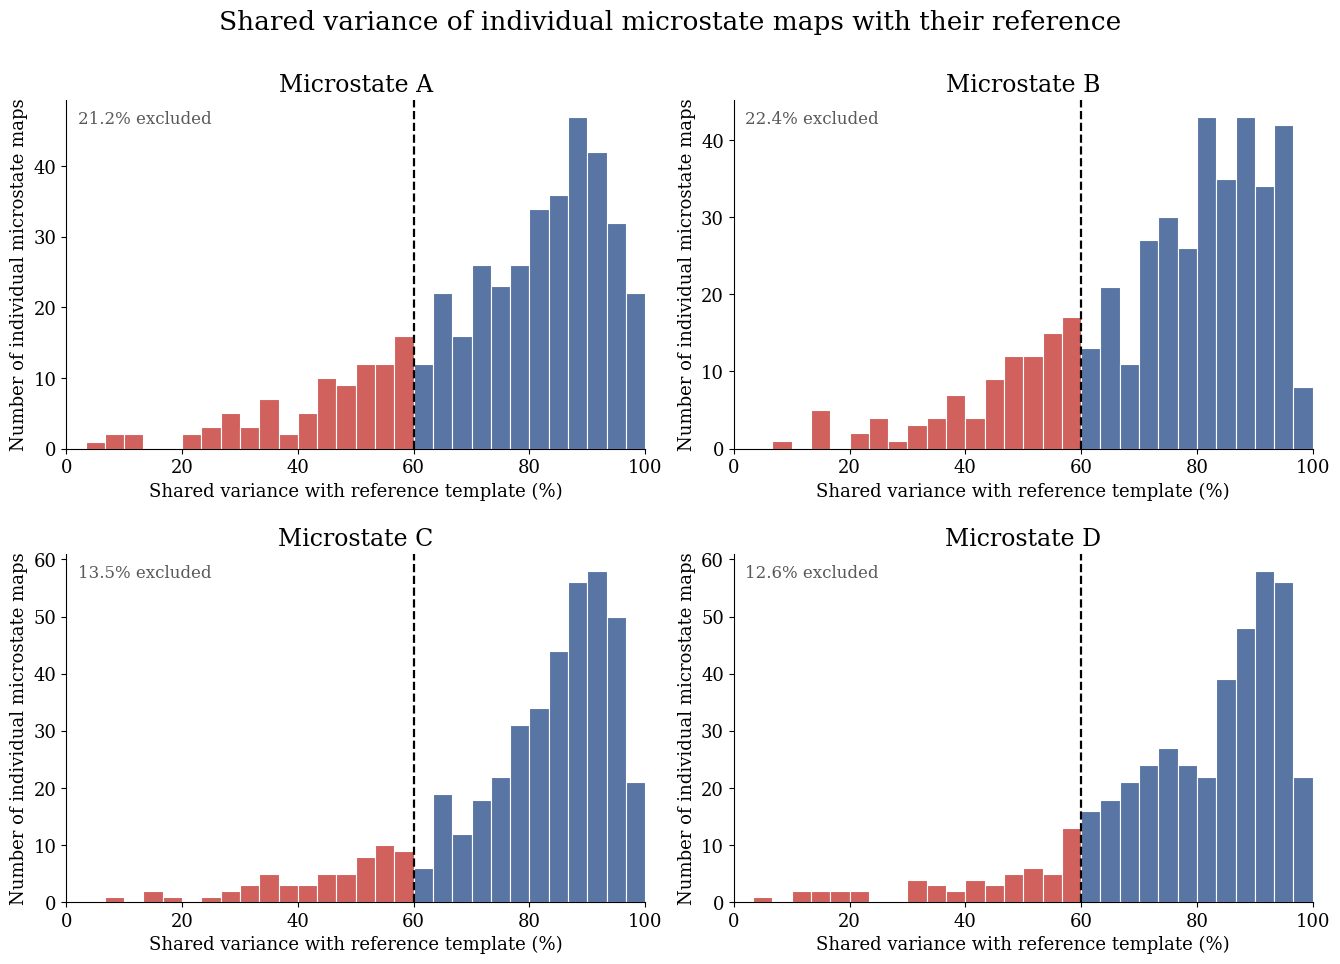

In [4]:
#: Individual maps below the threshold are excluded from all later statistics.
EXCLUDED_COLOR = "#d1615d"
INCLUDED_COLOR = "#5875a4"

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.5))
fig.suptitle("Shared variance of individual microstate maps with their reference",
             fontsize=19, y=1.01)

# 60 falls exactly on a bin edge, so no bin straddles the threshold.
bins = np.linspace(0, 100, 31)

for ax, ms in zip(axes.flat, MICROSTATES):
    values = shared_tidy.loc[shared_tidy["Microstate"] == ms, "SharedVariance"]
    excluded = 100 * (values <= SHARED_VARIANCE_MIN).mean()

    _, edges, patches = ax.hist(values, bins=bins, edgecolor="white", linewidth=0.8)
    for patch, left in zip(patches, edges[:-1]):
        patch.set_facecolor(INCLUDED_COLOR if left >= SHARED_VARIANCE_MIN
                            else EXCLUDED_COLOR)

    ax.axvline(SHARED_VARIANCE_MIN, color="black", linestyle="--", linewidth=1.6)
    ax.text(0.02, 0.97, f"{excluded:.1f}% excluded", transform=ax.transAxes,
            fontsize=12, color="0.35", va="top")
    ax.set_title(f"Microstate {ms}", fontsize=17)
    ax.set_xlabel("Shared variance with reference template (%)", fontsize=13)
    ax.set_ylabel("Number of individual microstate maps", fontsize=13)
    ax.set_xlim(0, 100)

sns.despine(fig=fig)
fig.tight_layout(h_pad=2.0)
fig.savefig(FIGURES / "shared_variance.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES / "shared_variance.pdf", bbox_inches="tight")
plt.show()

In [5]:
def apply_quality_control(frame: pd.DataFrame, failing: pd.DataFrame,
                          blank_first_metric: bool = False) -> pd.DataFrame:
    """Blank the metrics of every dataset/microstate that failed QC.

    Returns a new frame; the input is not modified.  Aggregate metrics
    (``*All``) are blanked whenever any of a dataset's microstates fails,
    because they sum over all four.
    """
    out = frame.copy()
    eligible = METRICS if blank_first_metric else METRICS[1:]

    for dataset, microstate in zip(failing["Dataset"], failing["Microstate"]):
        rows = out["Dataset"] == dataset
        if not rows.any():
            continue
        columns = [c for c in eligible if f"_{microstate}" in c]
        columns += [c for c in METRICS if "All" in c]
        out.loc[rows, columns] = np.nan
    return out


qc = apply_quality_control(microstates, failing, BLANK_FIRST_METRIC)

blanked = qc[METRICS].isna().sum().sum() - microstates[METRICS].isna().sum().sum()
print(f"blanked {blanked} of {qc[METRICS].size} metric values "
      f"({100 * blanked / qc[METRICS].size:.1f}%)")

blanked 2458 of 12870 metric values (19.1%)


In [6]:
# How many values BLANK_FIRST_METRIC affects.
qc_alternative = apply_quality_control(microstates, failing, blank_first_metric=True)
difference = qc[METRICS].notna() & qc_alternative[METRICS].isna()

print("values retained here that BLANK_FIRST_METRIC = True would drop:")
print(difference.sum()[difference.sum() > 0].to_string())

values retained here that BLANK_FIRST_METRIC = True would drop:


MeanDuration_A    91


## 3. Descriptive statistics

In [7]:
counts = (microstates
          .groupby(["psi/ctrl", "Condition", "Group"])
          .size()
          .unstack(fill_value=0)
          .reindex(pd.MultiIndex.from_product([SESSIONS, CONDITIONS],
                                              names=["psi/ctrl", "Condition"])))
counts["total"] = counts.sum(axis=1)
counts

Group                  meditator  non meditator  total
psi/ctrl Condition                                    
ctrl     video                29             24     53
         restingstate         31             28     59
         meditation           31             29     60
         music                31             29     60
psi      video                22             17     39
         restingstate         27             25     52
         meditation           28             26     54
         music                28             24     52

In [8]:
def matched_subjects(frame: pd.DataFrame, condition: str) -> set[str]:
    """Subjects with a usable recording in *both* sessions for ``condition``."""
    per_session = [set(frame.loc[(frame["Condition"] == condition)
                                 & (frame["psi/ctrl"] == session), "Subject"])
                   for session in SESSIONS]
    return set.intersection(*per_session)


pairs = pd.Series({c: len(matched_subjects(microstates, c)) for c in CONDITIONS},
                  name="paired subjects")
print(pairs.to_string())
print(f"\ntotal paired recordings: {2 * pairs.sum()}")

video           34
restingstate    48
meditation      51
music           49

total paired recordings: 364


In [9]:
def summarise(frame: pd.DataFrame, by: str) -> pd.DataFrame:
    return (frame.groupby(by)[["TotalExpVar", "TotalTime"]]
                 .agg(["mean", "std", "count"])
                 .round(4))


for key in ("psi/ctrl", "Group", "Condition"):
    print(f"--- by {key} ---")
    print(summarise(var_and_time, key).to_string(), "\n")

--- by psi/ctrl ---
         TotalExpVar               TotalTime               
                mean     std count      mean      std count
psi/ctrl                                                   
ctrl          0.6661  0.0711   232  268.3718  42.0705   232
psi           0.6584  0.0698   197  254.9247  43.6105   197 

--- by Group ---
              TotalExpVar               TotalTime               
                     mean     std count      mean      std count
Group                                                           
meditator          0.6598  0.0719   227  259.6658  45.2785   227
non meditator      0.6656  0.0691   202  265.0410  40.7921   202 

--- by Condition ---
             TotalExpVar               TotalTime               
                    mean     std count      mean      std count
Condition                                                      
meditation        0.6819  0.0628   114  266.1259  32.2781   114
music             0.6727  0.0600   112  288.1573  37.4263

## 4. Distributional screening

Each comparison below uses a parametric test when *both* samples pass a
Shapiro–Wilk normality test at p > 0.05, and the matching non-parametric test
otherwise.

In [10]:
def is_normal(values: pd.Series, alpha: float = 0.05) -> bool:
    """Shapiro–Wilk screen; too-small samples are treated as non-normal."""
    clean = pd.to_numeric(values, errors="coerce").dropna()
    if len(clean) < 3 or clean.nunique() < 2:
        return False
    return bool(scipy.stats.shapiro(clean).pvalue > alpha)


def independent_p(a: pd.Series, b: pd.Series) -> float:
    """t-test or Mann–Whitney U between two unpaired samples."""
    a = pd.to_numeric(a, errors="coerce").dropna()
    b = pd.to_numeric(b, errors="coerce").dropna()
    if len(a) < 3 or len(b) < 3:
        return np.nan
    if is_normal(a) and is_normal(b):
        return float(scipy.stats.ttest_ind(a, b).pvalue)
    return float(scipy.stats.mannwhitneyu(a, b).pvalue)


def paired_p(a: pd.Series, b: pd.Series) -> float:
    """Paired t-test or Wilcoxon signed-rank; pairs with a NaN are dropped."""
    both = pd.concat([pd.to_numeric(a, errors="coerce").reset_index(drop=True),
                      pd.to_numeric(b, errors="coerce").reset_index(drop=True)],
                     axis=1).dropna()
    if len(both) < 3:
        return np.nan
    left, right = both.iloc[:, 0], both.iloc[:, 1]
    if np.allclose(left, right):
        return 1.0
    if is_normal(left) and is_normal(right):
        return float(scipy.stats.ttest_rel(left, right).pvalue)
    return float(scipy.stats.wilcoxon(left, right).pvalue)


def add_fdr(results: pd.DataFrame, alpha: float = ALPHA) -> pd.DataFrame:
    """Benjamini–Hochberg over the whole table; NaN p-values stay NaN."""
    out = results.copy()
    usable = out["p"].notna()
    out["FDR"] = np.nan
    if usable.any():
        _, corrected = fdrcorrection(out.loc[usable, "p"], alpha=alpha)
        out.loc[usable, "FDR"] = corrected
    out["significant"] = out["FDR"] < alpha
    return out.sort_values("p", kind="stable").reset_index(drop=True)

## 5. Q1 — do MBCT and non-MBCT participants differ?

30 metrics x 4 conditions = 120 unpaired comparisons per session, corrected
within each session, exactly as reported in the paper (Supplementary Table S2).
Allocation to MBCT was not randomised and no EEG was recorded before training,
so this is an association with group membership, not an effect of training.

In [11]:
def compare_groups(frame: pd.DataFrame, session: str) -> pd.DataFrame:
    """MBCT vs non-MBCT within one session, for every condition and metric."""
    rows = []
    for condition, metric in itertools.product(CONDITIONS, METRICS):
        subset = frame[(frame["psi/ctrl"] == session)
                       & (frame["Condition"] == condition)]
        meditators = subset.loc[subset["Group"] == "meditator", metric]
        others = subset.loc[subset["Group"] == "non meditator", metric]
        rows.append({"Session": session, "Condition": condition,
                     "Metric": metric, "p": independent_p(meditators, others)})
    return pd.DataFrame(rows)


group_results = {session: add_fdr(compare_groups(qc, session))
                 for session in SESSIONS}

for session, table in group_results.items():
    n_sig = int(table["significant"].sum())
    print(f"{SESSION_LABELS[session]:>11s} session: {len(table)} tests, "
          f"{n_sig} significant after FDR (smallest FDR = {table['FDR'].min():.3f})")

pd.concat(group_results.values()).to_csv(RESULTS / "q1_mbct_group.csv", index=False)
group_results["ctrl"].head(10)

   baseline session: 120 tests, 0 significant after FDR (smallest FDR = 0.625)
 psilocybin session: 120 tests, 0 significant after FDR (smallest FDR = 0.301)


,Session,Condition,Metric,p,FDR,significant
0,ctrl,video,OrgTM_B->C,0.005211,0.625265,False
1,ctrl,video,OrgTM_A->D,0.022539,1.000000,False
2,ctrl,video,OrgTM_D->A,0.035027,1.000000,False
3,ctrl,video,Coverage_A,0.041468,1.000000,False
4,ctrl,video,OrgTM_C->B,0.059398,1.000000,False
5,ctrl,music,OrgTM_C->B,0.076480,1.000000,False
6,ctrl,video,MeanOccurrence_C,0.093983,1.000000,False
7,ctrl,music,OrgTM_B->C,0.094437,1.000000,False
8,ctrl,video,Coverage_B,0.161274,1.000000,False
9,ctrl,music,Coverage_C,0.163201,1.000000,False


In [12]:
# Session-by-group interaction: compare the within-participant change
# (psilocybin - baseline) between the two groups.
def session_change(frame: pd.DataFrame) -> pd.DataFrame:
    """One row per (subject, condition) holding psilocybin minus baseline."""
    wide = frame.pivot_table(index=["Subject", "Group", "Condition"],
                             columns="psi/ctrl", values=METRICS)
    delta = wide.xs("psi", axis=1, level=1) - wide.xs("ctrl", axis=1, level=1)
    return delta.reset_index()


deltas = session_change(qc)

rows = []
for condition, metric in itertools.product(CONDITIONS, METRICS):
    subset = deltas[deltas["Condition"] == condition]
    rows.append({"Condition": condition, "Metric": metric,
                 "p": independent_p(subset.loc[subset["Group"] == "meditator", metric],
                                    subset.loc[subset["Group"] == "non meditator", metric])})

interaction = add_fdr(pd.DataFrame(rows))
interaction.to_csv(RESULTS / "q1_mbct_interaction.csv", index=False)
print(f"session x group interaction: {len(interaction)} tests, "
      f"{int(interaction['significant'].sum())} significant after FDR")
interaction.head(5)

session x group interaction: 120 tests, 0 significant after FDR


,Condition,Metric,p,FDR,significant
0,music,OrgTM_D->A,0.020251,0.875026,False
1,video,MeanOccurrence_A,0.029899,0.875026,False
2,restingstate,OrgTM_C->A,0.032712,0.875026,False
3,meditation,OrgTM_A->D,0.039100,0.875026,False
4,meditation,MeanGFP_B,0.042737,0.875026,False


## 6. Q2 — effect of condition

All six pairwise comparisons among the four conditions, within each session.
Because every participant contributes to several conditions, these are paired
comparisons over the subjects present in both. FDR is applied jointly to all
30 metrics x 6 pairs x 2 sessions = 360 tests.

In [13]:
def compare_conditions(frame: pd.DataFrame) -> pd.DataFrame:
    """Every pairwise condition contrast, within each session, paired by subject."""
    rows = []
    for session, (first, second) in itertools.product(
            SESSIONS, itertools.combinations(CONDITIONS, 2)):
        left = frame[(frame["psi/ctrl"] == session) & (frame["Condition"] == first)]
        right = frame[(frame["psi/ctrl"] == session) & (frame["Condition"] == second)]
        merged = left.merge(right, on="Subject", suffixes=("_1", "_2"))
        for metric in METRICS:
            rows.append({"Session": session, "Comparison": f"{first} vs {second}",
                         "Metric": metric, "n": len(merged),
                         "p": paired_p(merged[f"{metric}_1"], merged[f"{metric}_2"])})
    return pd.DataFrame(rows)


condition_results = add_fdr(compare_conditions(qc))
condition_results.to_csv(RESULTS / "q2_condition.csv", index=False)

print(f"{len(condition_results)} tests, "
      f"{int(condition_results['significant'].sum())} significant after FDR\n")

significant = condition_results[condition_results["significant"]]
for session in SESSIONS:
    per_session = significant[significant["Session"] == session]
    with_video = per_session["Comparison"].str.contains("video").sum()
    print(f"{SESSION_LABELS[session]:>11s} session: {len(per_session)} significant, "
          f"{with_video} of them involve video")

360 tests, 95 significant after FDR

   baseline session: 58 significant, 46 of them involve video
 psilocybin session: 37 significant, 35 of them involve video


In [14]:
# Which metric families drive the video effect, and in which direction?
family = significant["Metric"].str.extract(r"^(MeanDuration|MeanOccurrence|Coverage|MeanGFP|OrgTM)")[0]
print(significant.assign(Family=family)
                 .groupby(["Session", "Family"], observed=True)
                 .size()
                 .unstack(fill_value=0)
                 .to_string())

Family   Coverage  MeanDuration  MeanGFP  MeanOccurrence  OrgTM
Session                                                        
ctrl            1            18       20              16      3
psi             0            12       13              12      0


In [15]:
def condition_means(frame: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    """Mean of each metric per session and condition, for reading off directions."""
    return (frame.groupby(["psi/ctrl", "Condition"])[metrics]
                 .mean()
                 .reindex(pd.MultiIndex.from_product([SESSIONS, CONDITIONS]))
                 .round(4))


headline = [f"{stem}_{ms}" for stem in ("MeanGFP", "MeanDuration", "MeanOccurrence")
            for ms in MICROSTATES]
condition_means(qc, headline).T

ctrl                                     psi               \
                   video restingstate meditation   music   video restingstate   
MeanGFP_A         4.3411       6.4940     5.9122  5.8326  4.1324       5.5095   
MeanGFP_B         4.2875       6.2900     5.7384  5.7172  4.0908       5.3187   
MeanGFP_C         4.3820       6.3244     5.8457  5.6022  4.3730       5.6413   
MeanGFP_D         4.2020       6.5362     5.9239  5.9026  4.1211       5.5017   
MeanDuration_A    0.0379       0.0499     0.0480  0.0469  0.0358       0.0403   
MeanDuration_B    0.0371       0.0491     0.0477  0.0469  0.0352       0.0412   
MeanDuration_C    0.0368       0.0477     0.0477  0.0455  0.0354       0.0407   
MeanDuration_D    0.0351       0.0485     0.0471  0.0458  0.0355       0.0400   
MeanOccurrence_A  7.1046       5.4213     5.3263  5.6542  7.3326       6.5850   
MeanOccurrence_B  7.1483       5.1628     5.3968  5.5827  7.3075       6.6290   
MeanOccurrence_C  6.7990       5.4168     5.5128  5.6889  7.3468       6.4263   
MeanOccurrence_D  6.8565       5.2826     5.5212  5.6347  7.4239       6.3277   

                                     
                 meditation   music  
MeanGFP_A            4.9834  4.8374  
MeanGFP_B            5.2274  5.3705  
MeanGFP_C            5.2417  5.2650  
MeanGFP_D            5.2764  5.2963  
MeanDuration_A       0.0412  0.0408  
MeanDuration_B       0.0416  0.0425  
MeanDuration_C       0.0408  0.0408  
MeanDuration_D       0.0404  0.0401  
MeanOccurrence_A     6.3588  6.4227  
MeanOccurrence_B     6.3359  6.3490  
MeanOccurrence_C     6.4429  6.3822  
MeanOccurrence_D     6.4080  6.3891

## 7. Q3 — effect of psilocybin

The design is within-participant, so psilocybin is compared against baseline
with paired tests over the subjects recorded in both sessions, separately for
each condition. FDR is applied jointly across all 30 metrics x 4 conditions =
120 tests.

In [16]:
def compare_sessions(frame: pd.DataFrame) -> pd.DataFrame:
    """Psilocybin vs baseline within each condition, paired by subject."""
    rows = []
    for condition in CONDITIONS:
        baseline = frame[(frame["psi/ctrl"] == "ctrl") & (frame["Condition"] == condition)]
        drug = frame[(frame["psi/ctrl"] == "psi") & (frame["Condition"] == condition)]
        merged = baseline.merge(drug, on="Subject", suffixes=("_ctrl", "_psi"))
        for metric in METRICS:
            control_values = merged[f"{metric}_ctrl"]
            drug_values = merged[f"{metric}_psi"]
            paired = pd.concat([control_values, drug_values], axis=1).dropna()
            rows.append({
                "Condition": condition, "Metric": metric, "n": len(paired),
                "mean_ctrl": paired.iloc[:, 0].mean() if len(paired) else np.nan,
                "mean_psi": paired.iloc[:, 1].mean() if len(paired) else np.nan,
                "p": paired_p(control_values, drug_values)})
    out = pd.DataFrame(rows)
    out["direction"] = np.where(out["mean_psi"] > out["mean_ctrl"], "up", "down")
    return out


session_results = add_fdr(compare_sessions(qc))
session_results.to_csv(RESULTS / "q3_psilocybin.csv", index=False)

print(f"{len(session_results)} tests, "
      f"{int(session_results['significant'].sum())} significant after FDR\n")
print(session_results[session_results["significant"]]
      .groupby("Condition", observed=True).size().to_string())

120 tests, 41 significant after FDR

Condition
meditation      12
music           12
restingstate    15
video            2


In [17]:
def significance_table(results: pd.DataFrame, stem: str) -> pd.DataFrame:
    """FDR values for one metric family, conditions x microstates."""
    subset = results[results["Metric"].str.startswith(stem)]
    table = subset.pivot(index="Condition", columns="Metric", values="FDR")
    return table.reindex(CONDITIONS).round(4)


for stem in ("MeanOccurrence", "MeanDuration", "MeanGFP", "Coverage"):
    print(f"--- {stem}: FDR-corrected p-values ---")
    print(significance_table(session_results, stem).to_string(), "\n")

--- MeanOccurrence: FDR-corrected p-values ---
Metric        MeanOccurrenceAll  MeanOccurrence_A  MeanOccurrence_B  MeanOccurrence_C  MeanOccurrence_D
Condition                                                                                              
video                    0.0963            0.3020            0.6217            0.0761            0.0061
restingstate             0.0108            0.0001            0.0002            0.0002            0.0000
meditation               0.0009            0.0013            0.0000            0.0001            0.0007
music                    0.0033            0.0058            0.0033            0.0002            0.0001 

--- MeanDuration: FDR-corrected p-values ---
Metric        MeanDurationAll  MeanDuration_A  MeanDuration_B  MeanDuration_C  MeanDuration_D
Condition                                                                                    
video                  0.0676          0.0517          0.0401          0.7545          0.6217


In [18]:
# Directed transitions, reported separately in the paper.
transitions = session_results[session_results["Metric"].str.startswith("OrgTM")]
print("significant directed transitions (psilocybin vs baseline):")
print(transitions[transitions["significant"]]
      [["Condition", "Metric", "n", "mean_ctrl", "mean_psi", "direction", "FDR"]]
      .to_string(index=False))

significant directed transitions (psilocybin vs baseline):
   Condition     Metric  n  mean_ctrl  mean_psi direction      FDR
restingstate OrgTM_C->A 36   8.787289  8.035258      down 0.025994
restingstate OrgTM_B->D 31   8.044926  8.847777        up 0.025994


In [19]:
# Coverage should be near-conserved if psilocybin only changes switching speed:
# coverage ~= occurrence x duration.
coverage = session_results[session_results["Metric"].str.startswith("Coverage")]
print(f"significant coverage changes: {int(coverage['significant'].sum())} "
      f"of {len(coverage)}")

check = []
for condition in CONDITIONS:
    rows = session_results[session_results["Condition"] == condition]
    for ms in MICROSTATES:
        occurrence = rows[rows["Metric"] == f"MeanOccurrence_{ms}"].iloc[0]
        duration = rows[rows["Metric"] == f"MeanDuration_{ms}"].iloc[0]
        check.append({
            "Condition": condition, "Microstate": ms,
            "occurrence change (%)": 100 * (occurrence["mean_psi"] / occurrence["mean_ctrl"] - 1),
            "duration change (%)": 100 * (duration["mean_psi"] / duration["mean_ctrl"] - 1),
        })
pd.DataFrame(check).round(2).pivot(index="Condition", columns="Microstate")

significant coverage changes: 0 of 16


occurrence change (%)                      duration change (%)  \
Microstate                       A      B      C      D                   A   
Condition                                                                     
meditation                   17.79  22.06  17.84  14.85              -14.30   
music                        13.87  13.41  13.06  15.09              -12.47   
restingstate                 19.14  25.91  19.02  21.93              -20.28   
video                         4.26   3.19   6.97  10.19               -5.14   

                                   
Microstate        B      C      D  
Condition                          
meditation   -15.39 -13.57 -13.15  
music        -11.77 -12.31 -11.43  
restingstate -13.04 -15.82 -17.82  
video         -8.70  -1.16  -2.27

## 8. Figure 1 — occurrence, duration and GFP

In [20]:
def paired_datasets(frame: pd.DataFrame) -> pd.DataFrame:
    """Recordings from subjects present in both sessions for their condition."""
    keep = pd.concat([
        frame[(frame["Condition"] == condition)
              & frame["Subject"].isin(matched_subjects(frame, condition))]
        for condition in CONDITIONS])
    return keep.copy()


plot_data = paired_datasets(qc)
print(f"{len(plot_data)} recordings from matched pairs enter the figure")

364 recordings from matched pairs enter the figure


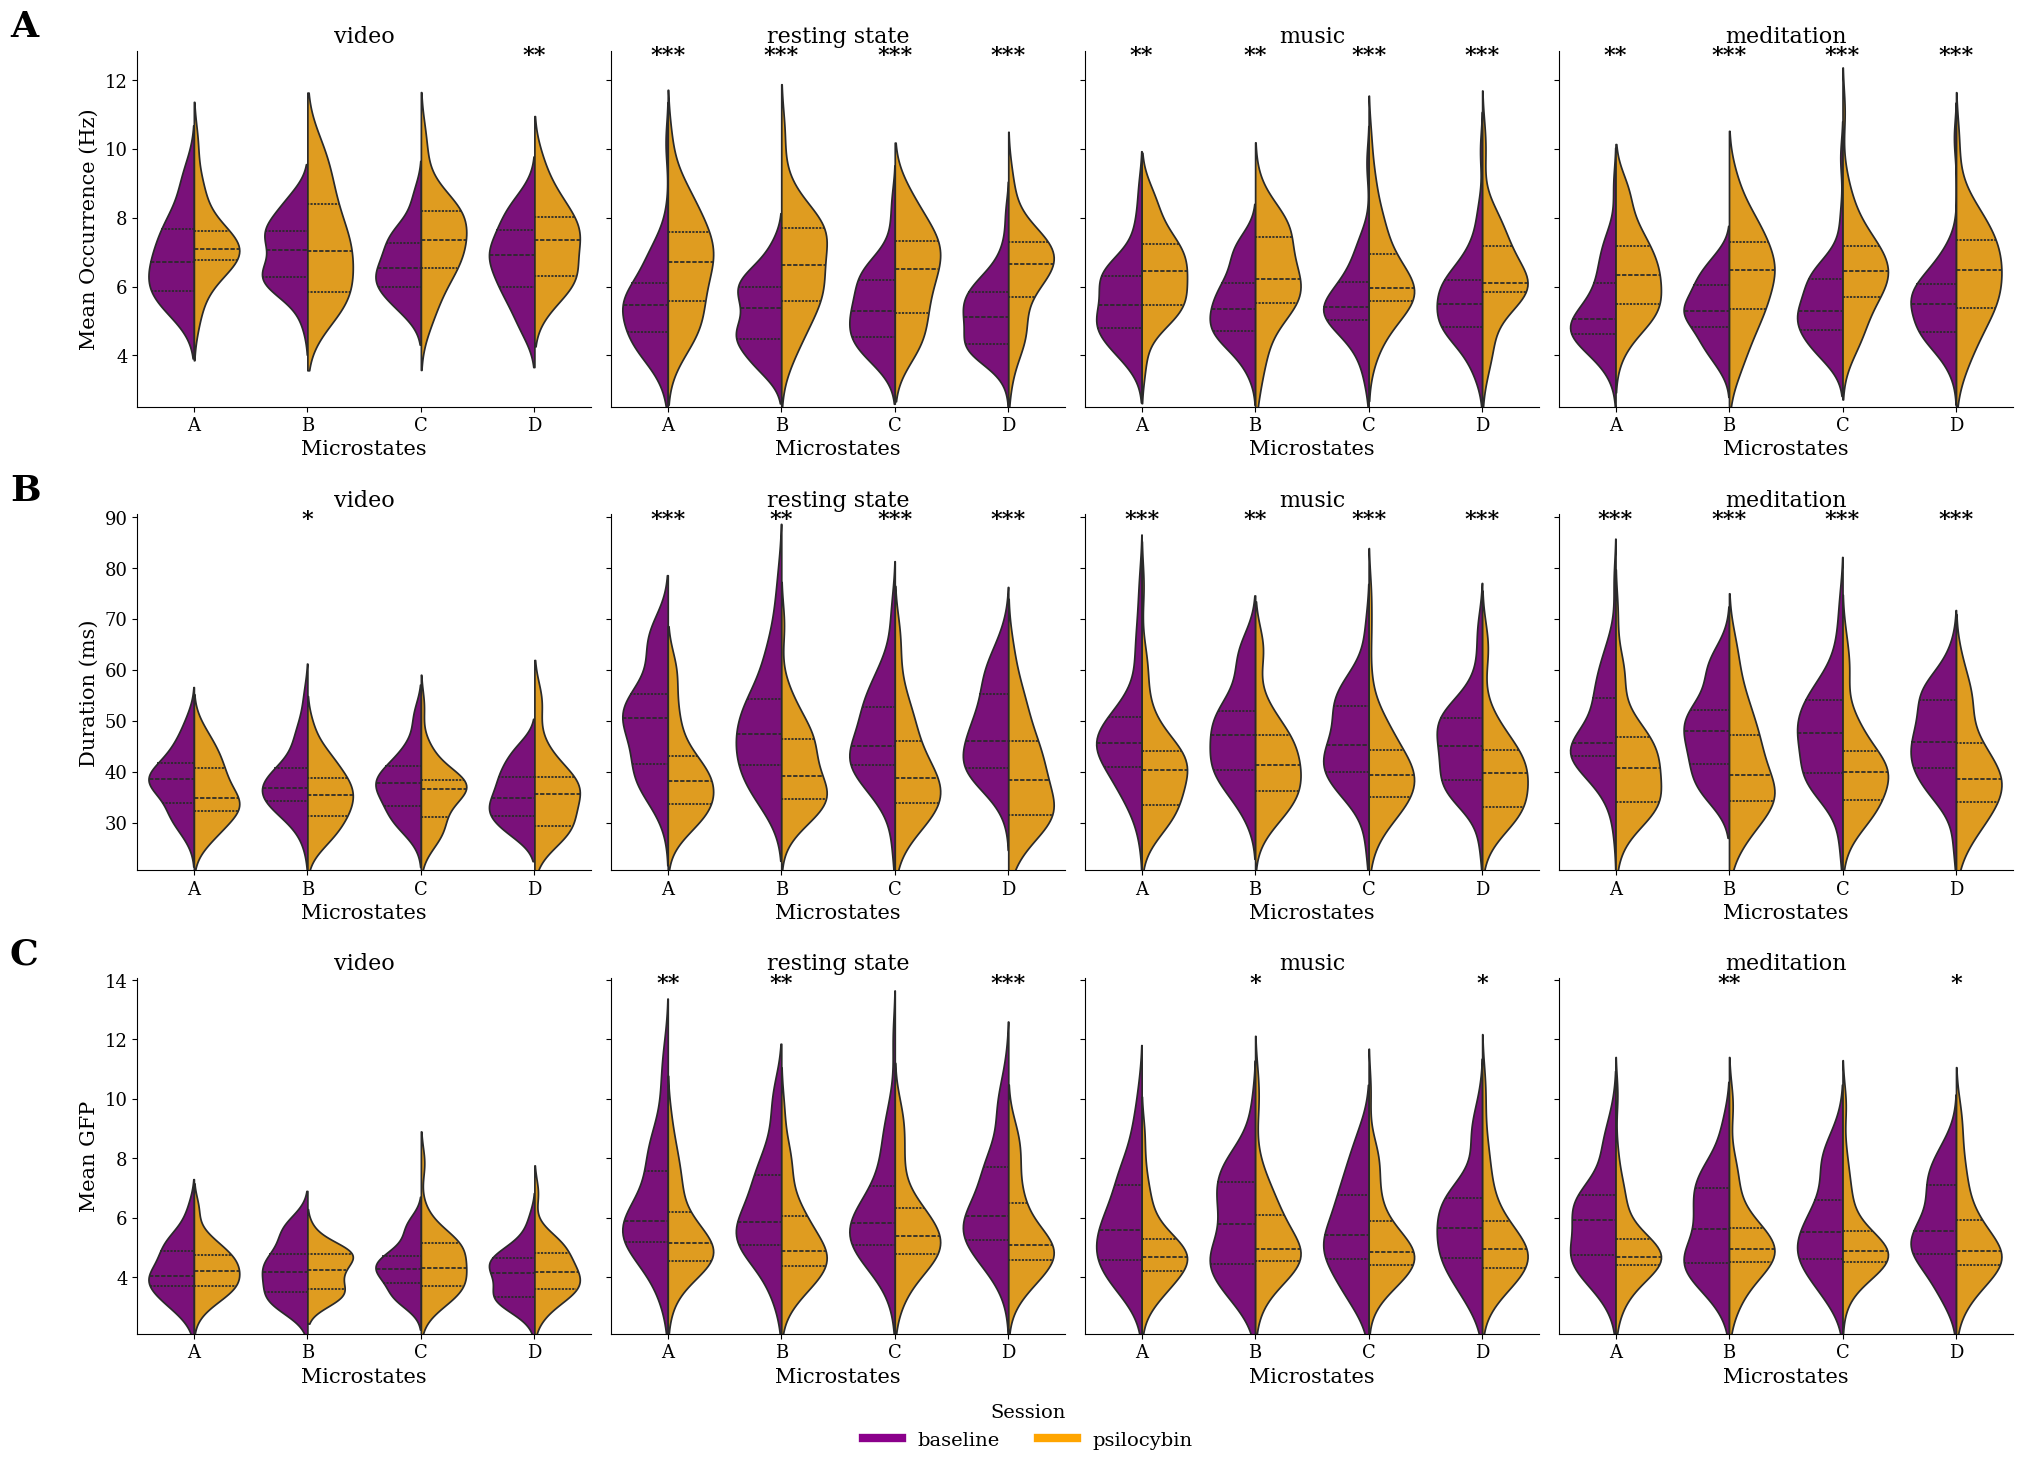

In [21]:
PANELS = (
    ("MeanOccurrence", "Mean Occurrence (Hz)", 1.0),
    ("MeanDuration", "Duration (ms)", 1000.0),
    ("MeanGFP", "Mean GFP", 1.0),
)
#: Condition order as laid out in the paper.
PANEL_CONDITIONS = ("video", "restingstate", "music", "meditation")
CONDITION_TITLES = {"video": "video", "restingstate": "resting state",
                    "meditation": "meditation", "music": "music"}


def stars(fdr: float) -> str:
    if fdr < 0.001:
        return "***"
    if fdr < 0.01:
        return "**"
    if fdr < ALPHA:
        return "*"
    return ""


def panel_frame(frame: pd.DataFrame, stem: str, scale: float) -> pd.DataFrame:
    columns = [f"{stem}_{ms}" for ms in MICROSTATES]
    melted = frame.melt(id_vars=["Condition", "psi/ctrl"], value_vars=columns,
                        var_name="Metric", value_name="value")
    melted["value"] *= scale
    melted["Microstate"] = melted["Metric"].str[-1]
    return melted.dropna(subset=["value"])


fig, axes = plt.subplots(3, 4, figsize=(20, 14.5))

for row, (stem, ylabel, scale) in enumerate(PANELS):
    melted = panel_frame(plot_data, stem, scale)
    ymin, ymax = melted["value"].min(), melted["value"].max()
    span = ymax - ymin
    # Generous headroom so the significance markers sit clear of the violins.
    bottom, top = ymin - 0.06 * span, ymax + 0.22 * span

    for col, condition in enumerate(PANEL_CONDITIONS):
        ax = axes[row, col]
        subset = melted[melted["Condition"] == condition]
        sns.violinplot(data=subset, x="Microstate", y="value", hue="psi/ctrl",
                       hue_order=SESSIONS, order=MICROSTATES, split=True,
                       inner="quart", palette=SESSION_COLORS, legend=False,
                       density_norm="width", ax=ax)
        ax.set_ylim(bottom, top)
        ax.set_xlabel("Microstates")
        ax.set_ylabel(ylabel if col == 0 else "")
        ax.set_title(CONDITION_TITLES[condition])
        if col > 0:
            ax.set_yticklabels([])

        for x, ms in enumerate(MICROSTATES):
            match = session_results[(session_results["Condition"] == condition)
                                    & (session_results["Metric"] == f"{stem}_{ms}")]
            if match.empty:
                continue
            marker = stars(match["FDR"].iloc[0])
            if marker:
                # Axes-fraction height, so markers align in a row across the
                # panel and never overlap a violin.
                ax.text(x, 0.955, marker, transform=ax.get_xaxis_transform(),
                        ha="center", va="bottom", fontsize=16, fontweight="bold")

for row, letter in enumerate("ABC"):
    axes[row, 0].text(-0.28, 1.02, letter, transform=axes[row, 0].transAxes,
                      fontsize=26, fontweight="bold", va="bottom")

handles = [mlines.Line2D([], [], color=SESSION_COLORS[s], lw=6,
                         label=SESSION_LABELS[s]) for s in SESSIONS]
# Below the panels: anywhere inside the grid collides with a title or a marker.
fig.legend(handles=handles, title="Session", loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.015), fontsize=14, title_fontsize=14,
           frameon=False)

sns.despine(fig=fig)
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(FIGURES / "figure1_microstate_dynamics.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES / "figure1_microstate_dynamics.pdf", bbox_inches="tight")
plt.show()

Asterisks mark FDR-corrected paired comparisons between the psilocybin and
baseline sessions: `*` p < 0.05, `**` p < 0.01, `***` p < 0.001.

## 9. Summary

In [22]:
summary = pd.DataFrame([
    {"question": "Q1 MBCT group (baseline)",
     "tests": len(group_results["ctrl"]),
     "significant": int(group_results["ctrl"]["significant"].sum())},
    {"question": "Q1 MBCT group (psilocybin)",
     "tests": len(group_results["psi"]),
     "significant": int(group_results["psi"]["significant"].sum())},
    {"question": "Q1 session x group interaction",
     "tests": len(interaction), "significant": int(interaction["significant"].sum())},
    {"question": "Q2 effect of condition",
     "tests": len(condition_results),
     "significant": int(condition_results["significant"].sum())},
    {"question": "Q3 effect of psilocybin",
     "tests": len(session_results),
     "significant": int(session_results["significant"].sum())},
])
summary.to_csv(RESULTS / "microstates_summary.csv", index=False)
summary

,question,tests,significant
0,Q1 MBCT group (baseline),120,0
1,Q1 MBCT group (psilocybin),120,0
2,Q1 session x group interaction,120,0
3,Q2 effect of condition,360,95
4,Q3 effect of psilocybin,120,41
